# Métriques, données déséquilibrées et sélection de modèles

Ce notebook fait suite au notebook d'introduction: les modèles sont maintenant supposés connus,
on s'intéresse à la manière de les **évaluer** et de les **comparer** correctement.

**Progression du notebook**: on part des *métriques de base* et de leurs pièges sur un problème équilibré (A.1),
on passe au *compromis précision/rappel* (A.2), puis au cas **déséquilibré** qui impose de raisonner en
*courbe ROC* (A.3) et de résumer cette courbe par un indicateur unique, l'*AUC* (A.4).
On rend ensuite l'évaluation **robuste** avec la validation croisée et les tests de significativité (B),
avant d'utiliser ce protocole pour **sélectionner** modèles et hyper-paramètres (C).
La partie D propose des exercices complémentaires indépendants.

**Conventions**: les cellules à compléter sont signalées par un commentaire `TODO` dans la version étudiante ;
les blocs <span style="color:red">Exo</span> / <span style="color:red">Mini-exo</span> sont de courts
exercices d'application immédiate.

<a id="sec-plan"></a>
## Plan

* [Préambule: usage d'outils externes](#sec-preambule)
* [A. Usage des métriques](#sec-a)
    * [A.1 Utiliser les métriques scikit-learn](#sec-a1)
    * [A.2 Courbe de compromis précision/rappel](#sec-a2)
    * [A.3 Cas déséquilibré, biais et courbe ROC](#sec-a3)
    * [A.4 Agrégation d'indicateurs: l'AUC](#sec-a4)
* [B. Evaluation robuste: la validation croisée](#sec-b)
    * [B.1 Exemples de fonctionnement](#sec-b1)
    * [B.2 Votre tour](#sec-b2)
    * [B.3 Résultats significatifs](#sec-b3)
* [C. Sélection de modèles](#sec-c)
    * [C.1 Processus classique](#sec-c1)
    * [C.2 Grid-search](#sec-c2)
    * [C.3 Votre tour](#sec-c3)
* [D. Exercices complémentaires](#sec-d)
    * [D.1 Métriques multi-classes: micro, macro, pondéré](#sec-d1)
    * [D.2 Choisir un seuil de décision à partir d'un coût métier](#sec-d2)
    * [D.3 Traiter le déséquilibre: pondération et rééchantillonnage](#sec-d3)
    * [D.4 ROC ou précision/rappel? le piège du très fort déséquilibre](#sec-d4)
    * [D.5 Les métriques de régression](#sec-d5)
    * [D.6 Validation croisée imbriquée: pourquoi un grid-search est optimiste](#sec-d6)
* [Annexe: transformation du notebook en version étudiante](#sec-annexe)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn


<a id="sec-preambule"></a>
## Préambule: usage d'outils externes

Nous allons continuer à utiliser la méthode `plot_frontiere`... Mais nous allons arrêter de la copier de
notebook en notebook. La solution est la suivante:

1. Faire un fichier `.py` avec la méthode
2. [option, mais plus propre] Mettre cette fonction dans un sous-répertoire (= création d'un module)
3. Importer la fonction avec les commandes ci-dessous

**ATTENTION** en plus de l'import, il faut ajouter une petite commande astucieuse (`autoreload`) qui vérifie si
le fichier externe a été modifié et recharge le module lorsque c'est nécessaire: sans elle, une correction
apportée à `outils/frontiere.py` resterait invisible tant que le noyau n'est pas redémarré.


In [2]:
from outils.frontiere import plot_frontiere

%load_ext autoreload
%autoreload 2

<a id="sec-a"></a>
## A. Usage des métriques

Toujours se rappeler que la métrique n'est pas nécessairement la fonction optimisée:
1. Spécificités des données et de la tâche $\Rightarrow$ définition de la fonction **cout**/**loss** à optimiser
   (c'est elle que l'algorithme d'apprentissage minimise, elle doit être dérivable, convexe, ... = contraintes
   mathématiques)
2. Présentation des résultats à un expert métier $\Rightarrow$ usage d'une **métrique** parlante
   (elle n'a aucune contrainte de forme, elle doit juste avoir du sens pour le problème traité)

Pour les approches précision/rappel, toujours garder en mémoire la super-illustration wikipedia:

<img src="fig/precision_rappel.png" width = "400px">


Text(0.5, 1.0, 'Données jouets équilibrées')

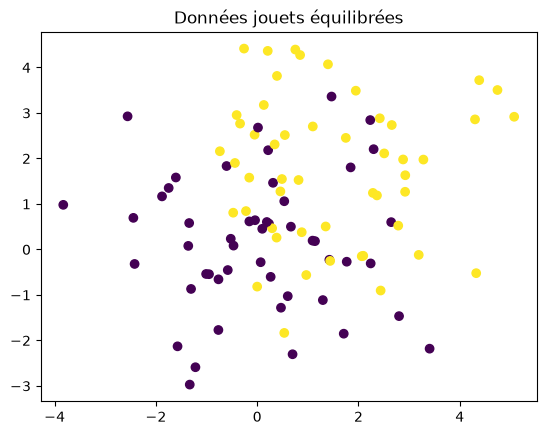

In [3]:
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

# données équilibrées (cas simple pour démarrer): 100 pts, 2 classes, 2 dimensions
centers      = [[0,0], [1.5,1.5]]
clusters_std = [1.5,1.5]
X, y = make_blobs(n_samples=100, centers=centers, cluster_std=clusters_std, n_features=2, random_state=0)
y    = y * 2 - 1                 # passage des étiquettes de {0,1} sur {-1,+1}
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=0)

plt.figure(facecolor='white')
plt.scatter(X[:,0], X[:,1], c=y)
plt.title("Données jouets équilibrées")


Text(0.5, 1.0, 'SVC Linéaire')

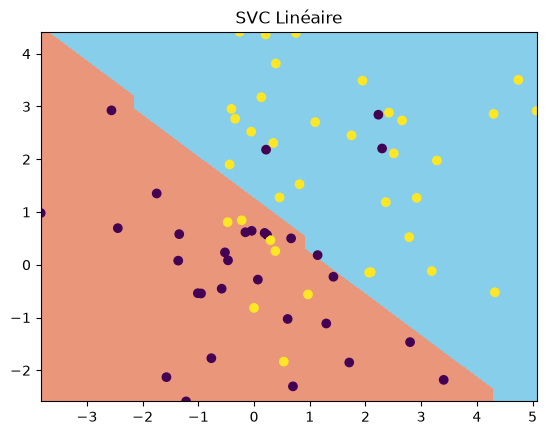

In [4]:
# modèle linéaire de référence pour toute la partie A.1
from sklearn.svm import LinearSVC

mod = LinearSVC(dual='auto')     # dual='auto' évite un warning de dépréciation de scikit-learn
mod.fit(X_train, y_train)

plt.figure(facecolor='white')
plot_frontiere(X_train, y_train, mod)
plt.scatter(X_train[:,0], X_train[:,1], c=y_train)
plt.title('SVC Linéaire')


<a id="sec-a1"></a>
### A.1 Utiliser les métriques scikit-learn

Toutes les métriques sont regroupées dans le module `sklearn.metrics` et partagent la même signature
`metrique(y_vrai, y_predit)` (**attention à l'ordre des arguments**):
[liste complète](https://scikit-learn.org/stable/modules/classes.html#sklearn-metrics-metrics).

Commençons par la métrique de base, l'*accuracy* (= taux de bonne classification), en apprentissage et en test.


In [5]:
# Exploitation et affichage des métriques
import sklearn.metrics as met

print("Accuracies (app/test) : ", met.accuracy_score(y_train, mod.predict(X_train)), \
    met.accuracy_score(y_test, mod.predict(X_test)))


Accuracies (app/test) :  0.8507462686567164 0.6363636363636364


L'accuracy résume tout en un seul chiffre... au prix d'une perte d'information: elle ne dit pas *quelle* classe
est mal traitée. Détaillons donc classe par classe.

1. Calculer la précision et le rappel de chacune des classes
    * Commencer par un appel simple à la fonction: combien de scores sont-ils calculés? A quoi
      correspondent-ils? (indice: regarder l'argument `pos_label`)
    * Il est important de noter que la précision et le rappel sont des métriques **complémentaires**: prises
      indépendamment, elles sont triviales à maximiser (cf. expérience juste après)
2. Calculer le score f1, qui est leur moyenne harmonique

**Note: à vous de faire les bons import pour accéder aux fonctions**


In [6]:
# import
# calcul des métriques

y_hat = mod.predict(X_test)

print(met.recall_score(y_test, y_hat,pos_label=1))
print(met.recall_score(y_test, y_hat,pos_label = -1))

print(met.precision_score(y_test, y_hat,pos_label=1))
print(met.precision_score(y_test, y_hat,pos_label = -1))

0.7857142857142857
0.5263157894736842
0.55
0.7692307692307693


Afin de vérifier la complémentarité entre précision et rappel, nous allons faire une petite expérience:

1. Construire une prédiction (directement en numpy) ne contenant que des +1 (i.e. le classifieur le plus bête
   possible: *tout est positif*)
2. Calculer les scores de précision et de rappel par rapport à la vérité terrain: est-ce que ça correspond à
   votre intuition?


In [7]:
# construire une prédiction absurde: tout le monde dans la classe +1

y_hat_faux = np.ones(len(y_hat))
print(y_hat_faux)

print(met.precision_score(y_test, y_hat_faux,pos_label=1))
print(met.precision_score(y_test, y_hat_faux,pos_label = -1))

print(met.recall_score(y_test, y_hat_faux,pos_label=1))
print(met.recall_score(y_test, y_hat_faux,pos_label = -1))


[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1.]
0.42424242424242425
0.0
1.0
0.0


c:\Users\Sahbine\Cours_IODAA\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Affichage avancé:

1. Calculer et afficher la matrice de confusion en identifiant clairement la notion de *VP, FP, VN, FN*
   (ie Vrais Positifs, Faux Positifs, Vrais Négatifs, Faux Négatifs).
    * Convention scikit-learn: les **lignes** sont les classes réelles, les **colonnes** les classes prédites,
      les classes étant rangées dans l'ordre croissant des étiquettes (ici -1 puis +1)
    * Bonus: afficher la matrice avec `imshow` puis ajouter les effectifs sur la figure ; il existe aussi une
      classe qui le fait directement, `ConfusionMatrixDisplay`

    <img src="fig/confmat2.png">


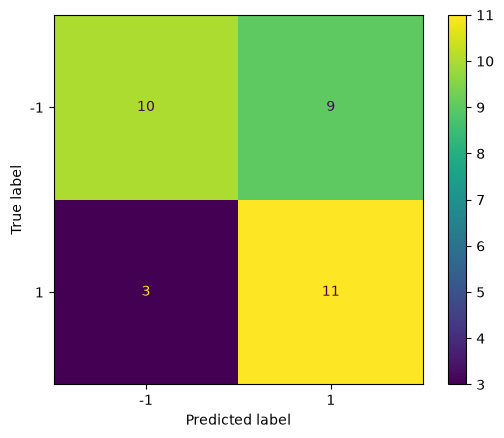

In [29]:
# matrice de confusion:
#  1. la calculer avec la métrique adaptée
#  2. utiliser la classe ConfusionMatrixDisplay pour l'affichage

Conf_mat = met.confusion_matrix(y_test, y_hat, labels=[-1, 1])

disp= met.ConfusionMatrixDisplay(Conf_mat, display_labels=[-1, 1])
disp.plot()
plt.show()


#### <span style="color:red">Exo</span> Calculer la précision et le rappel sur USPS

Passons à un problème réel et **multi-classes**: les chiffres manuscrits USPS (images 16x16, soit 256
caractéristiques, 10 classes).

1. Apprendre un modèle de votre choix (bayésien naïf, SVM, forêt aléatoire, ...)
2. Pour chaque classe de chiffre, calculer la précision et le rappel
3. Interpréter rapidement les résultats: quels chiffres sont les plus difficiles?

**Note**: les données USPS sont rangées dans des variables préfixées par `u` (`Xu_train`, ...) pour ne pas
écraser les données jouets `X_train`/`y_train` utilisées dans le reste de la partie A.


In [8]:
# Chargement des données
import pickle as pkl

data = pkl.load(open("data/usps.pkl", 'rb'))
# data est un dictionnaire contenant les champs explicites X_train, X_test, Y_train, Y_test
Xu_train = np.array(data["X_train"], dtype=float)  # changement de type pour éviter les problèmes d'affichage
Xu_test  = np.array(data["X_test"], dtype=float)
Yu_train = data["Y_train"]
Yu_test  = data["Y_test"]

print("USPS: {} exemples d'apprentissage, {} de test, {} caractéristiques, {} classes".format(
    *Xu_train.shape, Xu_test.shape[0], len(np.unique(Yu_train))))


USPS: 6229 exemples d'apprentissage, 256 de test, 3069 caractéristiques, 10 classes


[2 0 6 ... 1 8 3]
[0.82377049 0.99029126 0.73954984 0.61923077 0.24183007 0.3852459
 0.91954023 0.94680851 0.50446429 0.6227758 ]
[0.92626728 0.90066225 0.8778626  0.88950276 0.7628866  0.85454545
 0.5955335  0.62971698 0.40942029 0.40792541]


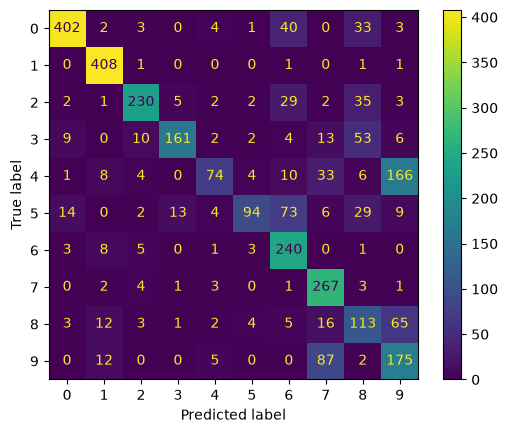

In [9]:
from sklearn import naive_bayes

# modèle (au choix) et métriques par classe
mod1 = naive_bayes.GaussianNB() 

mod1.fit(Xu_train, Yu_train)
yhat = mod1.predict(Xu_test)

print(yhat)

print(met.recall_score(Yu_test, yhat,average=None))
print(met.precision_score(Yu_test, yhat,average=None))

Conf_mat = met.confusion_matrix(Yu_test, yhat, labels=[0,1,2,3,4,5,6,7,8,9])

disp= met.ConfusionMatrixDisplay(Conf_mat, display_labels=[0,1,2,3,4,5,6,7,8,9])
disp.plot()
plt.show()

<a id="sec-a2"></a>
### A.2 Courbe de compromis précision/rappel

Un classifieur ne renvoie pas seulement une classe: il calcule d'abord un **score continu** (`decision_function`
ou `predict_proba`) qu'il seuille pour décider. Déplacer ce seuil ne change pas le modèle appris, mais change le
compromis obtenu: plus on est exigeant, plus la précision monte et plus le rappel descend.

L'idée est donc d'évaluer **l'ensemble des variations** d'un classifieur, et non un seul point de fonctionnement:

1. On apprend un classifieur (déjà fait: `mod`)
2. Le système fait varier le seuil, calcule les précisions et rappels et stocke les résultats

    Comment interpréter la figure suivante?

    <img src="fig/precrapp2.png">

    * Prenez la place d'un donneur d'ordre: comment exploiter cette courbe au niveau industriel?
      Mini-exo à suivre.

**Note: à vous de faire les bons import pour accéder aux fonctions**


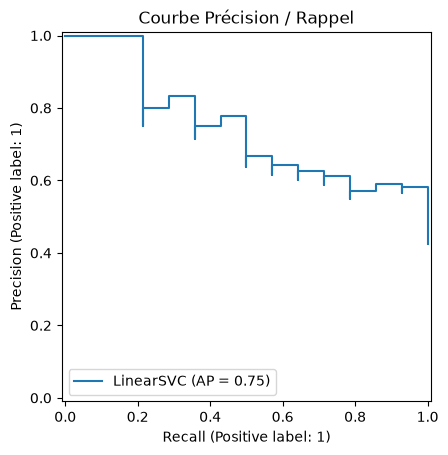

In [10]:
# Courbe de compromis précision/rappel
# (utiliser la classe PrecisionRecallDisplay et sa méthode from_estimator)
disp = met.PrecisionRecallDisplay.from_estimator(mod, X_test, y_test, pos_label=1)

plt.title("Courbe Précision / Rappel")
plt.show()

#### <span style="color:red">Mini-exo</span> Interprétation de la précision et du rappel

En imaginant dans le problème précédent que la classe -1 correspond à une situation normale et la classe +1 à
une alarme, utiliser la figure précédente pour répondre aux questions suivantes:

1. Si je ne tolère aucune fausse alerte, quelle couverture puis-je espérer avec cet estimateur?
2. Si je veux une couverture de 100% des alarmes, quel taux de fausse alerte vais-je avoir?


# question 1

<a id="sec-a3"></a>
### A.3 Cas déséquilibré, biais et courbe ROC

Attention, dans la suite, on se place dans le cas où la classe minoritaire est la classe d'intérêt (fraude,
alarme, anomalie, ...) et on va parler de **détection correcte (= VP vrai positif = TP true positive)** et de
**fausse alarme (= FP faux positif / False Positive)**.

C'est le cas le plus fréquent en pratique... et celui où l'accuracy devient trompeuse.

1. La génération des données est fournie
2. Ajouter le calcul du score en accuracy, **en anticipant le résultat avant de le lancer**


répartition des classes (test):  {np.int64(-1): 67, np.int64(1): 4}


Text(0.5, 1.0, 'Données déséquilibrées')

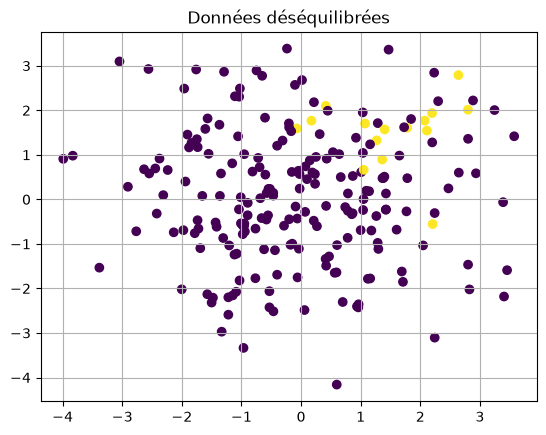

In [11]:
from sklearn.datasets import make_blobs

np.random.seed(42)
# données déséquilibrées: 200 pts "normaux" (classe -1) contre 15 "évènements" (classe +1)
centers      = [[0,0], [1.5, 1.5]]
clusters_std = [1.5, 0.75]
X, y = make_blobs(n_samples=[200,15], centers=centers, cluster_std=clusters_std, n_features=2, random_state=0)
y    = y * 2 - 1                 # passage des étiquettes de {0,1} sur {-1,+1}
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=0)

print("répartition des classes (test): ", {c: int((y_test==c).sum()) for c in np.unique(y_test)})

plt.figure(facecolor='white')
plt.scatter(X[:,0], X[:,1], c=y)
plt.grid()
plt.title("Données déséquilibrées")
# plt.savefig("fig/unbalanced.pdf")


In [ ]:
# modèle linéaire
from sklearn.svm import LinearSVC

mod = LinearSVC(dual='auto')
mod.fit(X_train, y_train)

plt.figure(facecolor='white')
plot_frontiere(X_train, y_train, mod)
plt.scatter(X_train[:,0], X_train[:,1], c=y_train)
plt.title('SVC Linéaire')
# plt.savefig("fig/unbalanced_dec.pdf")

# Ajouter le score en accuracy (en anticipant le résultat):
print("score supposé : ", 0.9)


Ce résultat illustre la difficulté à traiter des données déséquilibrées... Heureusement, il y a une première
solution simple pour obtenir des résultats:
* on peut **décaler la frontière de décision** (= ajouter un biais $b$ au score) jusqu'à ce qu'un point bascule
  dans la classe des détectés
* puis itérer le processus jusqu'à ce que 100% des points cibles soient détectés
* cet ensemble de classifieurs correspond à autant d'évaluations...
    * on retrouve la courbe précision/rappel vue précédemment
    * et on en profite pour introduire la **courbe ROC**
      ([lien](https://fr.wikipedia.org/wiki/Courbe_ROC)) qui trace les TP en fonction des FP

$$\text{Soit } X,Y : \forall b_i \in [\hat y_{max},\ \hat y_{min}] \text{ calculer } score(f(X)+b_i,Y) $$

> Courbe ROC = mesure de la capacité à détecter les évènements sans rajouter de bruit en faisant varier la
> sensibilité

<img src="fig/roc_anim3.gif">

**Note:** Pour obtenir l'animation facilement, on sauvegarde les images intermédiaires et on passe par un site
de création de GIF comme [ezgif](https://ezgif.com/maker/).

**Etape 1**: jouons avec la courbe ROC telle que scikit-learn la fournit.


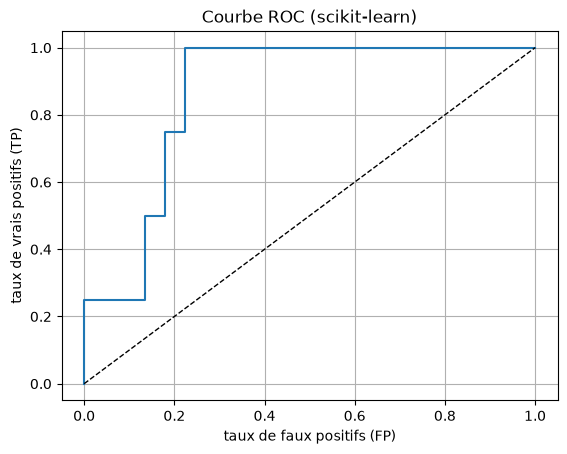

In [12]:
# 1. Dans mon problème, calcul de la valeur de sortie (score continu) du classifieur
#    decision_function = X @ coef_ + intercept_ : à préférer au produit matriciel écrit à la main

yhat = mod.decision_function(X_test)

# 2. Récupération de tous les seuils de coupure associés aux taux de vrais / faux positifs

fpr, tpr, thresholds = met.roc_curve(y_test, yhat, pos_label=1)

# 3. Tracé de la courbe ROC

plt.figure(facecolor='white')
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], 'k--', lw=1)   # diagonale = classifieur aléatoire
plt.xlabel('taux de faux positifs (FP)')
plt.ylabel('taux de vrais positifs (TP)')
plt.title('Courbe ROC (scikit-learn)')
plt.grid()


**Etape 2**: refaisons ce calcul *à la main* en faisant varier le biais, afin de comprendre ce que chaque point
de la courbe ROC représente réellement (un classifieur différent).

<span style="color:red"> **CETTE QUESTION EST DIFFICILE, ON PEUT LA TRAITER EN FIN DE SEANCE, ELLE N'EST PAS
BLOCANTE POUR LA SUITE** </span>


In [ ]:
# fabrication d'une courbe ROC

# 1. Calcul des scores des points de test:
yhat = mod.decision_function(X_test)  # ATTENTION, la fonction de score continue dépend du classifieur ;
                                      # seule la fonction de prédiction de classe discrète (predict) est
                                      # générique à tous les modèles de scikit-learn

# 2. Vérification: presque tous les scores sont négatifs (un seul point dépasse le seuil de décision)
#    => quasiment aucune détection, cohérent avec l'accuracy trompeuse ci-dessus
print(yhat)
print("nombre de points au-dessus du seuil: ", (yhat > 0).sum(), "/", len(yhat))

plt.figure(facecolor='white')
plt.bar(np.arange(len(yhat)), yhat)
plt.axhline(0, color='k', lw=1)       # le seuil de décision par défaut
plt.xlabel("indice du point de test")
plt.ylabel("score du classifieur")
plt.grid()


In [ ]:
# 3. On applique l'idée clé:
#   a. décaler la frontière (en fonction des valeurs de yhat)
#   b. calculer le score du nouveau classifieur

TP  = [0.]  # liste des taux de True Positive
FP  = [0.]  # liste des taux de False Positive
ACC = [np.where((y_test*yhat>0), 1, 0).mean()]  # contrôle sur le taux de bonne classification générale

# position initiale (0,0): 0 détecté, 0 fausse détection

nb_evt    = np.where((y_test>0), 1, 0).sum()   # pour normaliser les TP entre 0 et 1
nb_max_fp = np.where((y_test<=0), 1, 0).sum()  # pour normaliser les FP entre 0 et 1

plt.figure(figsize=[15,5], facecolor='white')

# détermination des valeurs de biais à tester
values = np.sort(-yhat[y_test>0])       # les valeurs qui font basculer un évènement de plus dans la détection
values = np.insert(values, 0, 0)        # b=0: le classifieur d'origine, aucune détection
values = np.append(values, -yhat.min()) # la valeur extrême pour laquelle TOUS les points sont détectés

# boucle sur les biais
for i, b in enumerate(values):  # evolution du biais b
    # 1. Décaler yhat (dans une nouvelle variable)
    # 2. calculer TP, FP et accuracy
    # 3. faire les affichages
    #    - c'est un peu long... Pas besoin de peaufiner (réglage des axes...)

    ###  TODO  ###

# NB: seule la dernière figure de la boucle reste affichée dans le notebook (plt.clf efface les précédentes) ;
# l'intérêt est de sauvegarder les images intermédiaires pour en faire un GIF.


In [ ]:
# Bilan de la partie A.3: la courbe ROC construite à la main et la courbe précision/rappel décrivent
# le MEME ensemble de classifieurs, vus sous deux angles différents.

###  TODO  ###


<a id="sec-a4"></a>
### A.4 Agrégation d'indicateurs: l'AUC

Les data-scientists ont horreur de manipuler différents indicateurs: pour fusionner **précision** et **rappel**,
on a calculé le **f1-score**. Evidemment, la courbe ROC pose le même problème: il s'agit d'une liste de scores,
difficile à expliquer à un expert métier.

Pour la courbe ROC, l'idée est de calculer l'aire sous la courbe (**AUC: Area Under the Curve**):
- plus la courbe passe *en haut à gauche*, plus l'aire couverte est grande (i.e. on a bien détecté les
  évènements sans ajouter de bruit) $\Rightarrow$ l'aire tend vers 1
- plus la courbe passe *sur la diagonale*, plus l'aire couverte est petite (i.e. à chaque mouvement, on ajoute
  autant de détection que de bruit) $\Rightarrow$ l'aire tend vers 0.5

<img src="fig/auc.png">

**Interprétation probabiliste** (utile pour convaincre un expert métier): l'AUC est la probabilité qu'un
évènement tiré au hasard reçoive un score plus élevé qu'un non-évènement tiré au hasard. Un tirage à pile ou
face donne donc 0.5.

Pour l'implémentation, il suffit de se référer à l'exemple donné ici:
[lien](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.auc.html).


In [ ]:
# Calculer l'indicateur AUC correspondant au problème précédent:
# 1. Reprendre les calculs de fpr, tpr de la courbe ROC
# 2. Trouver la fonction auc qui calcule l'aire sous la courbe
# 3. Bonus: colorier l'aire sous la courbe construite à la main

###  TODO  ###


<a id="sec-b"></a>
## B. Evaluation robuste: la validation croisée

On a déjà vu ci-dessus la fonction de séparation d'un jeu de données en apprentissage et test: elle marche très
bien dans la plupart des cas.

`X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=0)`

Mais avec peu de données, le score obtenu dépend fortement du tirage: changer le `random_state` peut faire
bouger la performance de plusieurs points. Cette section explique comment passer à la **validation croisée**,
qui moyenne le score sur plusieurs découpages et fournit en prime un écart-type.

Deux solutions principales sont proposées dans scikit-learn:
1. Boucle `for` (les objets `KFold` / `StratifiedKFold` ne fournissent que les **indices**):
    * séparation des données
    * apprentissage
    * évaluation sur les données de test
2. Lancement d'une fonction effectuant toutes les opérations et retournant les scores en test
   (`cross_val_score`):
    * rapide, pratique
    * facilement parallélisable (cf. argument `n_jobs`)
    * non adapté quand on veut avoir la main sur les données intermédiaires

**Note:** afin d'être robuste au cas déséquilibré, il est plus efficace de prendre les options `stratified`
(`StratifiedKFold`) qui garantissent la même répartition des classes en apprentissage et en test. C'est le
comportement par défaut de `cross_val_score` en classification.


<a id="sec-b1"></a>
### B.1 Exemples de fonctionnement

On revient à des données équilibrées pour comparer les deux écritures sur un cas simple.


Text(0.5, 1.0, 'Données jouets équilibrées')

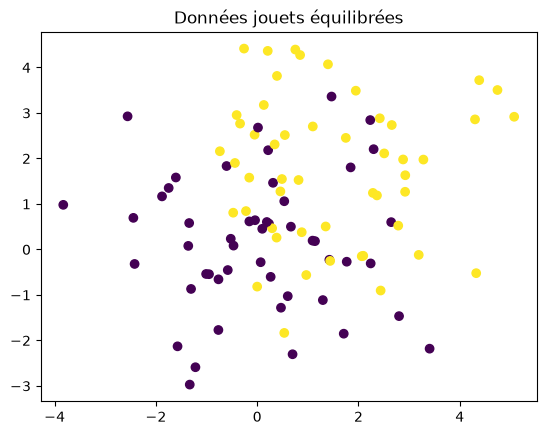

In [13]:
# Génération des données (on repart de données équilibrées, sans séparation app/test:
# c'est la validation croisée qui va s'en charger)
centers      = [[0,0], [1.5,1.5]]
clusters_std = [1.5,1.5]
X, y = make_blobs(n_samples=100, centers=centers, cluster_std=clusters_std, n_features=2, random_state=0)
y    = y * 2 - 1

plt.figure(facecolor='white')
plt.scatter(X[:,0], X[:,1], c=y)
plt.title("Données jouets équilibrées")


In [14]:
# Solution 1: la boucle explicite (on garde la main sur chaque fold)

from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

n_fold = 5

skf = StratifiedKFold(n_splits=n_fold)  # objet validation croisée stratifiée

allp = []
for train, test in skf.split(X, y):     # récupération des index (et non des données)
    mod = SVC()                         # ATTENTION: un modèle NEUF à chaque fold
    mod.fit(X[train], y[train])
    yhat = mod.predict(X[test])
    perf = accuracy_score(y[test], yhat)
    allp.append(perf)
    print('perf : ', perf)

print('Estimation moyenne : {:.3f} (+/- {:.3f})'.format(np.mean(allp), np.std(allp)))


perf :  0.75
perf :  0.75
perf :  0.6
perf :  0.85
perf :  0.75
Estimation moyenne : 0.740 (+/- 0.080)


In [15]:
# Solution 2: la fonction toute faite
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC

# définition du modèle (non appris: cross_val_score le clone et l'apprend sur chaque fold)
mod    = SVC()
n_fold = 5

scores = cross_val_score(mod, X, y, cv=n_fold, scoring='accuracy')  # tout est caché dedans :)
print(scores)
print('Estimation moyenne : {:.3f} (+/- {:.3f})'.format(scores.mean(), scores.std()))

# on retrouve exactement les valeurs de la solution 1: cross_val_score utilise StratifiedKFold par défaut
# en classification. L'argument scoring accepte le nom de n'importe quelle métrique
# ('f1', 'roc_auc', 'balanced_accuracy', ...): cf sklearn.metrics.get_scorer_names()


[0.75 0.75 0.6  0.85 0.75]
Estimation moyenne : 0.740 (+/- 0.080)


<a id="sec-b2"></a>
### B.2 Votre tour

Sur ces données jouets, calculer la performance en validation croisée d'un modèle bayésien naïf, d'un SVM
linéaire et d'une forêt aléatoire. Sélectionner le modèle le plus performant.

**Note:** on se limite aux modèles avec les paramètres par défaut. [la solution est donc très courte]


In [ ]:
# validation croisée des 3 modèles, puis sélection du meilleur

###  TODO  ###


<a id="sec-b3"></a>
### B.3 Résultats significatifs

Savoir si un modèle est meilleur qu'un autre n'est pas si simple... Distinguons néanmoins très grossièrement
3 cas de figure:

1. Très peu de données (<50), potentiellement avec de nombreuses classes ou en régression: le problème est dur
   et nécessite une approche statistique très solide.
2. Beaucoup de données (>10000) et éventuellement peu de classes (e.g. MNIST): le problème est très simple...
   La moindre amélioration à $10^{-2}$ en accuracy est souvent significative.
3. Le cas intermédiaire... Jeu de taille moyenne. Dans ce cas, on peut directement utiliser une fonction toute
   faite (!): `paired_ttest_kfold_cv`. Un tuto très simple est illustré ici:
   [lien](https://rasbt.github.io/mlxtend/user_guide/evaluate/paired_ttest_kfold_cv/)

Le test est **apparié** (*paired*): on compare les deux modèles sur *les mêmes* découpages, ce qui élimine la
variabilité due au tirage des folds et rend le test beaucoup plus sensible.

Comparer les résultats SVC / Naive Bayes et tester la significativité des résultats:


In [ ]:
# si nécessaire (à ne lancer qu'une fois, puis à recommenter)
%pip install mlxtend


In [ ]:
# comparaison SVC / GaussianNB avec un test t apparié sur les folds

###  TODO  ###


<a id="sec-c"></a>
## C. Sélection de modèles

L'idée est à la fois de trouver la meilleure classe de modèle (déjà fait ci-dessus)... mais aussi les
paramètres optimaux des modèles. Le terme **sélection de modèle** regroupe les deux problématiques, qui se
traitent avec exactement le même outil: une boucle sur les candidats + un protocole d'évaluation honnête.


<a id="sec-c1"></a>
### C.1 Processus classique

1. Liste des modèles (ici: un même SVM à noyau gaussien, pour plusieurs valeurs de $\gamma$)
2. Evaluation

**Note:** on peut utiliser la validation croisée si on manque de données, ou une procédure plus simple
(app/test) si la masse est suffisante.

**Note 2:** globalement, le processus est très proche de la section précédente... On se contente de faire
varier un hyper-paramètre au lieu de changer de famille de modèle.


In [ ]:
# Data
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

# données équilibrées
centers      = [[0,0], [1.5,1.5]]
clusters_std = [1.5,1.5]
X, y = make_blobs(n_samples=100, centers=centers, cluster_std=clusters_std, n_features=2, random_state=0)
y    = y * 2 - 1
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=0)

plt.figure(facecolor='white')
plt.scatter(X[:,0], X[:,1], c=y)
plt.title("Données jouets équilibrées")


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

param = [0.01, 0.05, 0.1, 0.5, 1, 5]
allp  = []
plt.figure(facecolor='white', figsize=[4*len(param),4])

for i, gam in enumerate(param):
    mod = SVC(gamma=gam)
    mod.fit(X_train, y_train)
    yhat = mod.predict(X_test)
    perf = accuracy_score(y_test, yhat)
    allp.append(perf)

    # affichage
    plt.subplot(1, len(param), i+1)
    plot_frontiere(X, y, mod)
    plt.scatter(X_train[:,0], X_train[:,1], c=y_train)
    plt.title(r'SVC $\gamma=${}, perf={:.2f}'.format(gam, perf))

print("meilleur gamma (au sens du test): ", param[int(np.argmax(allp))])
# ATTENTION: ce gamma a été choisi EN REGARDANT les données de test => l'estimation de performance
# associée est optimiste. Le protocole correct est celui de C.2 (choix en validation croisée sur
# les données d'apprentissage), et l'exercice D.6 quantifie le biais introduit ici.


<a id="sec-c2"></a>
### C.2 Grid-search

Ce que l'on a fait ci-dessus à la main correspond à ce que les data-scientists nomment *grid-search*: recherche
de valeur(s) optimale(s) sur un axe, ou sur une grille lorsqu'on a plusieurs paramètres.

Le code ci-dessous envisage deux cas de figure:

1. Reproduction de l'exemple précédent (recherche sur un axe) avec une fonction plus efficace
    * paramètre $\gamma$ du noyau gaussien dans un SVM
2. Recherche sur deux axes (= grille) $\Rightarrow$ à vous de jouer en C.3
    * paramètre $\gamma$ + paramètre de régularisation $C$

Différence majeure avec C.1: `GridSearchCV` évalue chaque candidat **en validation croisée sur les données
d'apprentissage uniquement**. Les données de test restent intactes pour l'estimation finale.

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html#

**Note:** la documentation est importante. Il est possible de définir partiellement des grilles (en passant une
*liste* de dictionnaires) lorsque les combinaisons de certains paramètres n'ont pas de sens.


In [ ]:
# Cas 1: recherche sur un axe
from sklearn.model_selection import GridSearchCV

# définition du modèle générique
mod = SVC()
# dictionnaire: key = nom du paramètre dans le classifieur
parameters = {'gamma' : [0.01, 0.05, 0.1, 0.5, 1, 5]}
meta_mod   = GridSearchCV(estimator=mod, param_grid=parameters, cv=3)
meta_mod.fit(X_train, y_train)          # la validation croisée est effectuée sur les données de train
print(meta_mod.cv_results_.keys())      # pour voir ce qui est disponible

# exploration
print(meta_mod.cv_results_['mean_test_score'])
print(meta_mod.cv_results_['params'])

# raccourcis très pratiques:
print("\nmeilleurs paramètres : ", meta_mod.best_params_)
print("score en validation croisée : {:.3f}".format(meta_mod.best_score_))
# par défaut refit=True: meta_mod a été réappris sur TOUT X_train avec les meilleurs paramètres
# => il s'utilise directement comme un modèle
print("score en test (jamais vu) : {:.3f}".format(meta_mod.score(X_test, y_test)))


<a id="sec-c3"></a>
### C.3 Votre tour

1. Ajouter une recherche du paramètre de régularisation $C$ sur le problème précédent. Vous devez obtenir une
   figure comme celle ci-dessous:

<img src ='fig/gridsearch.png'>

2. [@home] Trouver les paramètres optimaux d'une forêt aléatoire (nombre d'arbres et profondeur) pour ce
   problème.

**Indice pour la figure**: `cv_results_['mean_test_score']` est un vecteur *à plat*. Les combinaisons sont
énumérées dans l'ordre du produit cartésien des clés **triées par ordre alphabétique** (`C` puis `gamma`),
la dernière clé variant le plus vite: un `reshape(len(C), len(gamma))` suffit donc à retrouver la grille.


In [ ]:
# cas 2: recherche sur 2 axes
# Jouer avec le paramètre de régularisation C en plus du réglage de gamma

###  TODO  ###


In [ ]:
# Vérification de la cohérence du graphique ci-dessus (ordre d'énumération des combinaisons)
print([(p, a) for p, a in zip(meta_mod.cv_results_['params'], meta_mod.cv_results_['mean_test_score'])])


In [ ]:
# 2. [@home] forêt aléatoire: nombre d'arbres et profondeur

###  TODO  ###


<a id="sec-d"></a>
## D. Exercices complémentaires

Les exercices de cette partie sont indépendants les uns des autres (chacun régénère ses propres données) et
peuvent être traités dans le désordre, selon le temps disponible. Ils prolongent chacun un point précis des
parties A à C.

| Exercice | Notion travaillée | Prolonge |
|---|---|---|
| D.1 | métriques multi-classes: moyennes micro, macro et pondérée | A.1 |
| D.2 | choisir un seuil de décision à partir d'un coût métier asymétrique | A.2 |
| D.3 | traiter le déséquilibre: pondération des classes et rééchantillonnage | A.3 |
| D.4 | ROC ou précision/rappel? le piège du très fort déséquilibre | A.4 |
| D.5 | les métriques de régression, et leur sensibilité aux valeurs extrêmes | A |
| D.6 | validation croisée imbriquée: pourquoi le score d'un grid-search est optimiste | B, C |


<a id="sec-d1"></a>
### D.1 Métriques multi-classes: micro, macro, pondéré

Précision et rappel sont définis pour **une** classe. Avec 10 classes, on obtient 10 valeurs... qu'il faut bien
résumer à un moment. Scikit-learn propose pour cela l'argument `average`:

* `average=None`: pas d'agrégation, un score par classe
* `average='micro'`: on additionne les VP, FP, FN de toutes les classes *avant* de calculer le ratio
* `average='macro'`: moyenne **non pondérée** des scores par classe (chaque classe compte pour 1)
* `average='weighted'`: moyenne pondérée par l'effectif de chaque classe

1. Reprendre les données USPS et apprendre deux modèles (par exemple `GaussianNB` et `SVC`)
2. Pour chacun, afficher la précision et le rappel avec les quatre valeurs de `average`
3. Utiliser `classification_report` pour obtenir le tableau complet d'un coup
4. Répondre:
    * pourquoi la précision micro, le rappel micro et l'accuracy sont-ils **égaux** en classification
      multi-classes à étiquette unique?
    * dans quel cas la moyenne macro est-elle très différente de la moyenne pondérée, et laquelle faut-il
      choisir quand les classes rares sont les plus importantes?


In [ ]:
import pickle as pkl
import sklearn.metrics as met

data = pkl.load(open("data/usps.pkl", 'rb'))
Xu_train = np.array(data["X_train"], dtype=float)
Xu_test  = np.array(data["X_test"], dtype=float)
Yu_train, Yu_test = data["Y_train"], data["Y_test"]

###  TODO  ###


<a id="sec-d2"></a>
### D.2 Choisir un seuil de décision à partir d'un coût métier

La partie A.2 a montré qu'un classifieur offre **un continuum** de points de fonctionnement. Reste la question
que pose systématiquement un donneur d'ordre: *lequel choisir?* La réponse n'est pas dans les données, elle est
dans le **coût des erreurs**.

Contexte: détection de pannes sur une chaine de production. Une panne non détectée coûte 10 (arrêt de la
chaine), une fausse alerte coûte 1 (déplacement inutile d'un technicien).

1. Générer un jeu déséquilibré: `make_classification(n_samples=2000, n_features=10, n_informative=4,
   weights=[0.92, 0.08], random_state=0)` et le séparer en apprentissage / test
2. Apprendre une régression logistique et récupérer les probabilités `predict_proba(X_test)[:,1]`
3. Pour 500 seuils entre 0 et 1, calculer le coût total $c_{FN} \times FN + c_{FP} \times FP$ sur le jeu de test
4. Tracer le coût en fonction du seuil, repérer le seuil optimal et le comparer au seuil par défaut (0.5)
5. Recommencer avec $c_{FN} = 3$ puis $c_{FN} = 30$
6. Répondre:
    * de combien le coût baisse-t-il par rapport au seuil par défaut, *sans changer le modèle*?
    * dans quel sens le seuil optimal se déplace-t-il quand le coût d'une panne augmente? Que se passe-t-il
      dans le cas extrême, et qu'est-ce que cela dit du modèle?
    * pourquoi ce seuil devrait-il en toute rigueur être choisi sur un jeu de **validation** et non sur le test?


In [ ]:
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

Xd, yd = make_classification(n_samples=2000, n_features=10, n_informative=4,
                             weights=[0.92, 0.08], random_state=0)
Xd_app, Xd_test, yd_app, yd_test = train_test_split(Xd, yd, test_size=0.4, random_state=0)

###  TODO  ###


<a id="sec-d3"></a>
### D.3 Traiter le déséquilibre: pondération et rééchantillonnage

En A.3, on a *constaté* le problème du déséquilibre et on l'a contourné en déplaçant la frontière après coup.
On peut aussi agir **pendant** l'apprentissage. Trois stratégies classiques:

* **pondération**: `class_weight='balanced'` donne à chaque classe un poids inversement proportionnel à son
  effectif dans la fonction de coût (disponible sur la plupart des modèles scikit-learn)
* **sous-échantillonnage** (*undersampling*): on jette des exemples de la classe majoritaire
* **sur-échantillonnage** (*oversampling*): on duplique (ou on interpole, cf. SMOTE) des exemples de la
  classe minoritaire

1. Générer un jeu à 5% de positifs (`make_classification(..., weights=[0.95, 0.05], n_samples=2000)`)
2. Comparer quatre `LogisticRegression`: sans rien, avec `class_weight='balanced'`, avec sous-échantillonnage,
   avec sur-échantillonnage (le rééchantillonnage s'écrit en 3 lignes de numpy, ne se fait que sur
   l'**apprentissage**, jamais sur le test)
3. Reporter pour chacune: accuracy, `balanced_accuracy`, rappel et précision de la classe minoritaire, AUC
4. Répondre:
    * quelles métriques bougent, lesquelles ne bougent (presque) pas? Pourquoi l'AUC est-elle si stable?
    * quel lien peut-on faire entre ces trois stratégies et le simple déplacement de seuil de D.2?


In [ ]:
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

Xi, yi = make_classification(n_samples=2000, n_features=10, n_informative=4,
                             weights=[0.95, 0.05], random_state=1)
Xi_app, Xi_test, yi_app, yi_test = train_test_split(Xi, yi, test_size=0.4, random_state=0)
print("positifs en apprentissage: {}/{}".format(yi_app.sum(), len(yi_app)))

###  TODO  ###


<a id="sec-d4"></a>
### D.4 ROC ou précision/rappel? le piège du très fort déséquilibre

L'AUC (A.4) est l'indicateur le plus utilisé... et l'un des plus trompeurs en détection d'évènements rares.
La raison est dans les axes: le taux de faux positifs $FP/(FP+VN)$ a un **dénominateur énorme** quand les
négatifs sont très nombreux. Mille fausses alertes noyées dans un million de négatifs déplacent à peine la
courbe ROC... mais ruinent la précision, qui vaut $VP/(VP+FP)$ et ne regarde pas les VN du tout.

L'indicateur symétrique de l'AUC côté précision/rappel est l'**average precision**
(`average_precision_score`), c'est-à-dire l'aire sous la courbe précision/rappel.

Pour isoler proprement le phénomène, on ne va pas apprendre de modèle: on **simule directement les scores**
d'un classifieur de qualité fixée (scores gaussiens, décalés de 2.33 pour la classe positive, ce qui
correspond à une AUC de 0.95) et on fait uniquement varier le **taux de positifs**.

1. Pour un taux de positifs de 50%, 10%, 1% puis 0.1%, générer `y` puis les scores
   `sc = rng.randn(n) + 2.33*y` et calculer `roc_auc_score` et `average_precision_score`
2. Comparer chaque indicateur à sa valeur de référence pour un classifieur **aléatoire**
   (`sc = rng.rand(n)`)
3. Tracer côte à côte la courbe ROC (`RocCurveDisplay`) et la courbe précision/rappel
   (`PrecisionRecallDisplay`) dans le cas à 1%
4. Répondre:
    * lequel des deux indicateurs dépend du taux de positifs? Quelle est la valeur de référence
      (= niveau du hasard) de chacun?
    * un modèle affichant une AUC de 0.95 est-il exploitable en production sur un problème à 0.1% de
      positifs?
    * lequel des deux indicateurs faut-il présenter à un expert métier, et pourquoi?


In [ ]:
# on ne fait pas d'apprentissage ici: on simule directement les scores d'un classifieur
# de qualité fixée, et on ne fait varier que le taux de positifs

###  TODO  ###


<a id="sec-d5"></a>
### D.5 Les métriques de régression

Tout ce notebook porte sur la classification, mais le même raisonnement (la métrique n'est pas la loss, et un
seul chiffre ne suffit jamais) vaut en **régression**. Les trois métriques usuelles:

* **MAE** (`mean_absolute_error`): erreur moyenne en valeur absolue, dans l'unité de la variable cible
* **RMSE** (`mean_squared_error` puis racine): pénalise les grosses erreurs au carré
* **$R^2$** (`r2_score`): part de variance expliquée, sans unité — 1 = parfait, 0 = aussi bon que prédire la
  moyenne, négatif = pire que la moyenne

1. Charger `datasets.load_diabetes()`, séparer app/test, apprendre une `LinearRegression`
2. Afficher MAE, RMSE et $R^2$ en test, et tracer le nuage (valeur prédite, valeur réelle)
3. Polluer **une seule** valeur cible du jeu de **test** (la multiplier par 50) et recalculer les trois
   métriques *sans réapprendre*: on mesure ici la sensibilité de la **métrique**
4. Repartir des données propres et polluer cette fois une valeur cible du jeu d'**apprentissage**: on mesure
   la sensibilité du **modèle**
5. Répondre:
    * à l'étape 3, quelle métrique explose et laquelle résiste? Pourquoi?
    * à l'étape 4, l'effet est-il du même ordre? Que nous apprend la comparaison des deux étapes?
    * si le métier tolère mal les grosses erreurs ponctuelles, laquelle faut-il optimiser? Et si les données
      contiennent des valeurs aberrantes connues?


In [ ]:
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

Xg, yg = load_diabetes(return_X_y=True)
Xg_app, Xg_test, yg_app, yg_test = train_test_split(Xg, yg, test_size=0.33, random_state=0)

###  TODO  ###


<a id="sec-d6"></a>
### D.6 Validation croisée imbriquée: pourquoi un grid-search est optimiste

En C.2, `GridSearchCV` renvoie `best_score_`: le score en validation croisée de la meilleure combinaison
d'hyper-paramètres. La tentation est grande de publier ce chiffre... c'est une erreur.

En effet, on a choisi ce modèle **parce que** son score de validation croisée était le maximum sur toute la
grille. Le maximum d'un ensemble de mesures bruitées est *systématiquement* supérieur à la vraie valeur: une
partie du score obtenu est de la chance sur ces folds-là. La solution est la **validation croisée imbriquée**
(*nested cross-validation*): une boucle externe évalue, une boucle interne règle les hyper-paramètres.

1. Générer `make_classification(n_samples=150, n_features=20, n_informative=5, random_state=...)`
2. Faire un `GridSearchCV` sur un `SVC` (grille `C` × `gamma`, 36 combinaisons) et relever `best_score_`
3. Évaluer le **même objet `GridSearchCV`** avec `cross_val_score(grid, X, y, cv=5)`: chaque fold externe
   refait sa propre recherche d'hyper-paramètres sur ses seules données d'apprentissage
4. Répéter sur 5 jeux de données différents (`random_state` variable) pour vérifier que l'écart n'est pas
   un accident
5. Répondre:
    * quel est le sens de l'écart, et est-il systématique?
    * pourquoi le coût de calcul est-il le produit des deux nombres de folds par la taille de la grille?
    * dans un projet réel avec un jeu de test mis de côté, à quel moment ce problème se pose-t-il?


In [ ]:
from sklearn.datasets import make_classification
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.svm import SVC

###  TODO  ###


----
<a id="sec-annexe"></a>
## Annexe: transformation du notebook en version étudiante

La cellule ci-dessous produit `2-notebook-metrique.ipynb` à partir de ce fichier: tout ce qui se trouve entre
les balises de correction (dans les cellules de code **comme** dans les cellules de texte) est remplacé par
un `TODO`.

**À faire avant de la lancer**: `Kernel > Restart & Clear Output`, sinon les sorties des cellules de correction
(résultats et figures) restent visibles dans la version distribuée.


In [ ]:
###  TODO  ###
